In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]
all_features = analysis_run["feature_universe"]

In [2]:
labels = ds.cells.fetch("clusters", key="I")
source = labels == "Ductal"
sink = np.isin(labels, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink labels must both be present")
source_sink_vector = np.zeros(len(labels), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()
float(source_sink_vector.sum())

6.418476861114186e-17

In [3]:
pseudotime_ref = ds.run_pseudotime_scoring(
    graph,
    ss_vec=source_sink_vector,
)
pseudotime = ds.load_pseudotime_scoring(pseudotime_ref)
{
    "artifact": pseudotime.ref,
    "graph": pseudotime.graph,
    "valid cells": int(pseudotime.valid.sum()),
}

{'artifact': ArtifactRef(assay='RNA', kind='pseudotime', artifact_id='158c50af1179...'),
 'graph': ArtifactRef(assay='RNA', kind='connectivity_map', artifact_id='a0e45883d751...'),
 'valid cells': 3696}

<Axes: xlabel='umap_1', ylabel='umap_2'>

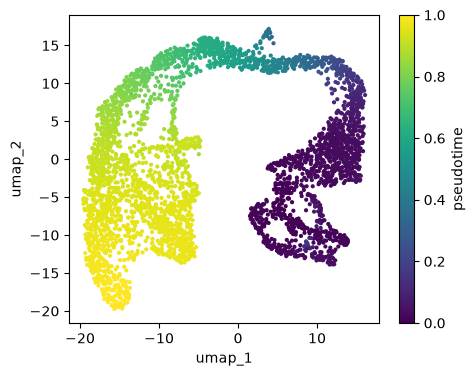

In [4]:
plot_data = analysis_run.cells.to_pandas_dataframe(["umap_1", "umap_2"])
plot_data["pseudotime"] = pseudotime.values
plot_data.loc[pseudotime.valid].plot.scatter(
    x="umap_1",
    y="umap_2",
    c="pseudotime",
    colormap="viridis",
    s=4,
    figsize=(5, 4),
)

In [5]:
pd.DataFrame(
    {
        "cluster": labels[pseudotime.valid],
        "pseudotime": pseudotime.values[pseudotime.valid],
    }
).groupby("cluster")["pseudotime"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
Alpha,481.0,0.958600,0.011519,0.854478,0.954543,0.961917,0.966559,0.975109
Beta,591.0,0.969641,0.020167,0.910871,0.955089,0.969660,0.986822,1.000000
Delta,70.0,0.920603,0.006220,0.903510,0.917825,0.921493,0.922952,0.943655
Ductal,916.0,0.022825,0.015730,0.000000,0.010842,0.023882,0.030093,0.120071
Epsilon,142.0,0.922423,0.029085,0.834411,0.908502,0.928372,0.946040,0.960314
Ngn3 high EP,642.0,0.499842,0.176005,0.086534,0.379658,0.548114,0.624802,0.769385
Ngn3 low EP,262.0,0.053563,0.037662,0.000263,0.029102,0.039294,0.077263,0.297250
Pre-endocrine,592.0,0.862448,0.061309,0.424159,0.814672,0.875902,0.916073,0.952458


In [6]:
marker_ref = ds.run_pseudotime_marker_search(
    pseudotime_ref,
    features=all_features,
)
markers = ds.load_pseudotime_markers(marker_ref)
markers.table[["p_value", "p_value_adjusted"]].notna().sum()

p_value             13821
p_value_adjusted    13821
dtype: int64

In [7]:
tested = markers.table.loc[
    markers.table["p_value_adjusted"].notna(),
    ["feature_name", "r_value", "p_value_adjusted"],
]
increasing = tested.loc[tested["r_value"] > 0].nlargest(10, "r_value")
decreasing = tested.loc[tested["r_value"] < 0].nsmallest(10, "r_value")
pd.concat({"increasing": increasing, "decreasing": decreasing})

feature_name   r_value  p_value_adjusted
increasing 14296         Gnas  0.733567               0.0
           23549          Cpe  0.727497               0.0
           21244        Aplp1  0.724603               0.0
           3186       Fam183b  0.667334               0.0
           25060        Hmgn3  0.634924               0.0
           26573         Bex2  0.622213               0.0
           26730       Pcsk1n  0.619926               0.0
           2189         Rap1b  0.598697               0.0
           4284           Ubb  0.596692               0.0
           5837          Scgn  0.593868               0.0
decreasing 18864         Spp1 -0.828276               0.0
           24581        Rpl13 -0.822456               0.0
           22385        Rps19 -0.813066               0.0
           16254         Rps8 -0.809460               0.0
           431            Dbi -0.798188               0.0
           19815        Rpl32 -0.783291               0.0
           26498        Rps4x -0.782105               0.0
           13425        Rpl12 -0.768214               0.0
           10164         Rps2 -0.754602               0.0
           20787        Mgst1 -0.745689               0.0